In [6]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, random_split, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

In [ ]:
import os
print("O Python acha que está aqui:", os.getcwd())

print("\nFicheiros que o Python consegue ver agora:")
print(os.listdir('.'))

O Python acha que está aqui: /home/heitor/Documents/Redes_Neurais-docs/Buffet_Brain

Ficheiros que o Python consegue ver agora:
['Buffet_Brain.ipynb', 'Buffet_venv', 'Gera_dados.py', 'dados_sequenciais_lstm.csv']


In [ ]:
df = pd.read_csv('dados_sequenciais_lstm.csv')
display(df.head())

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='perfil_final',hue='x', palette='viridis',legend=False)
plt.title('Distribuição de Perfis de Investidor')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='renda_mensal', y='tolerancia_risco', hue='perfil_final', alpha=0.6)
plt.title('Renda Mensal vs Tolerância ao Risco')
plt.show()

NameError: name 'pd' is not defined

In [ ]:

mapeamento_perfis = {'Conservador': 0, 'Moderado': 1, 'Audacioso': 2}
df['perfil_final'] = df['perfil_final'].map(mapeamento_perfis)

num_investidores = df['investidor_id'].nunique()
anos_seq = 4
features_cols = ['idade', 'renda_mensal', 'percentual_poupado', 'conhecimento_financeiro', 'tolerancia_risco']
num_features = len(features_cols)

X_3d = np.zeros((num_investidores, anos_seq, num_features))
y_1d = np.zeros(num_investidores)

for i, (id_invest, grupo) in enumerate(df.groupby('investidor_id')):
    X_3d[i] = grupo[features_cols].values
    y_1d[i] = grupo['perfil_final'].iloc[0] 

X_tensor = torch.FloatTensor(X_3d)
y_tensor = torch.LongTensor(y_1d)

X_mean = X_tensor.mean(dim=(0, 1), keepdim=True)
X_std = X_tensor.std(dim=(0, 1), keepdim=True)
X_scaled = (X_tensor - X_mean) / X_std

dataset = TensorDataset(X_scaled, y_tensor)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
class Guia_LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(Guia_LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)  
        last_hidden = lstm_out[:, -1, :] 
        out = self.fc(last_hidden)  
        return out

input_size = num_features
hidden_size = 64
num_classes = 3
num_layers = 1
historico_loss = []

modelo = Guia_LSTM(input_size, hidden_size, num_classes)
funcao_loss = nn.CrossEntropyLoss()
otimizador = optim.Adam(modelo.parameters(), lr=0.001)

num_epocas = 20
for epoch in range(num_epocas):
    modelo.train()
    loss_epoca = 0
    for X_batch, y_batch in train_loader:
        otimizador.zero_grad()
        outputs = modelo(X_batch)
        loss = funcao_loss(outputs, y_batch)
        loss.backward()
        otimizador.step()
        loss_epoca += loss.item()
    historico_loss.append(loss_epoca / len(train_loader))

    if (epoch+1) % 30 == 0:
        print(f'Época [{epoch+1}/{num_epocas}], Loss: {historico_loss:.4f}')
print("Treinamento Concluído!")

Treinamento Concluído!


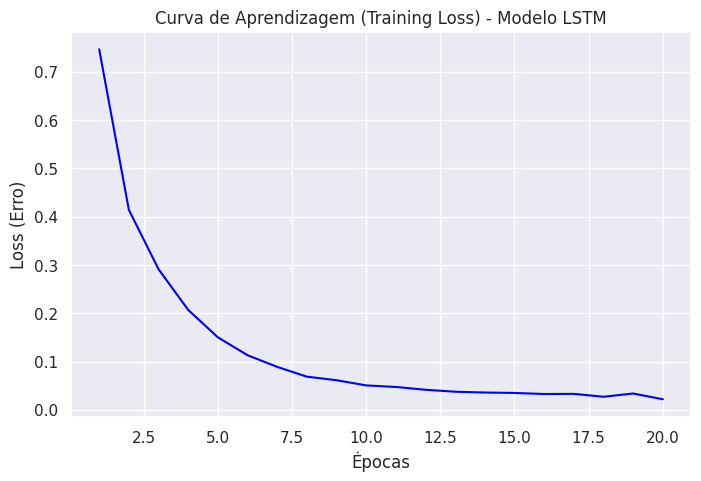

Exatidão (Acurácia) do modelo LSTM: 99.30%
Ficheiro lstm_guide gerado com sucesso!


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epocas + 1), historico_loss, color='blue')
plt.title('Curva de Aprendizagem (Training Loss) - Modelo LSTM')
plt.xlabel('Épocas')
plt.ylabel('Loss (Erro)')
plt.show()

modelo.eval()
correct, total = 0, 0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = modelo(batch_X)
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()

acuracia = (correct / total) * 100
print(f"Exatidão (Acurácia) do modelo LSTM: {acuracia:.2f}%")

torch.save({
    'model_state_dict': modelo.state_dict(),
    'X_mean': X_mean,
    'X_std': X_std,
    'mapeamento_reverso': {0: 'Conservador', 1: 'Moderado', 2: 'Audacioso'},
    'arquitetura': 'LSTM',
    'hidden_size': hidden_size
}, 'lstm_guide.pth')

print("Ficheiro lstm_guide gerado com sucesso!")